In [1]:
import os
import pandas as pd
import numpy as np

from scipy.signal import butter
from scipy.signal import filtfilt
from scipy.ndimage import median_filter


# =====================================
# DATASET PATH
# =====================================

ROOT = r"C:\Users\tarak\Patient_Files"

FS = 125
WINDOW = 1500


# =====================================
# ECG BANDPASS FILTER
# =====================================

def bandpass_ecg(x):

    b, a = butter(
        4,
        [
            0.5 / (FS / 2),
            40 / (FS / 2)
        ],
        btype="band"
    )

    return filtfilt(
        b,
        a,
        x
    )


# =====================================
# ADAPTIVE MEDIAN FILTER
# =====================================

def amf(x):

    return median_filter(
        x,
        size=5
    )


# =====================================
# NORMALIZATION
# =====================================

def normalize(x):

    return (

        x - np.mean(x)

    ) / (

        np.std(x) + 1e-8

    )


# =====================================
# SEGMENTATION
# =====================================

def segment(signal):

    out = []

    for i in range(

        0,

        len(signal),

        WINDOW

    ):

        s = signal[

            i:

            i + WINDOW

        ]

        if len(s) == WINDOW:

            out.append(
                s
            )

    return out


# =====================================
# LOAD CSV
# =====================================

ecg_segments = []

labels = []

files = sorted([

    f

    for f in os.listdir(ROOT)

    if f.endswith(".csv")

])


print(

"\nTotal Files:",

len(files)

)


# =====================================
# PROCESS EACH FILE
# =====================================

for file in files:

    path = os.path.join(

        ROOT,

        file

    )

    print(

        "Processing:",

        file

    )

    df = pd.read_csv(

        path

    )

    ecg = (

        df["ECG"]

        .values

        .astype(

            np.float32

        )

    )

    label = (

        df["label"]

        .iloc[0]

    )

    # FILTER

    ecg = bandpass_ecg(

        ecg

    )

    # AMF

    ecg = amf(

        ecg

    )

    # NORMALIZE

    ecg = normalize(

        ecg

    )

    # SEGMENT

    seg = segment(

        ecg

    )

    ecg_segments.extend(

        seg

    )

    labels.extend(

        [label]

        *

        len(seg)

    )


# =====================================
# SAVE
# =====================================

ecg_segments = np.array(

    ecg_segments,

    dtype=np.float32

)

labels = np.array(

    labels

)

print(

"\nECG Shape:",

ecg_segments.shape

)

print(

"Labels Shape:",

labels.shape

)


np.save(

    "ecg_segments2.npy",

    ecg_segments

)

np.save(

    "labels2.npy",

    labels

)


print(

"\nSaved"

)

print(

"ecg_segments2.npy"

)

print(

"labels2.npy"

)


Total Files: 35
Processing: Patient_1.csv
Processing: Patient_10.csv
Processing: Patient_11.csv
Processing: Patient_12.csv
Processing: Patient_13.csv
Processing: Patient_14.csv
Processing: Patient_15.csv
Processing: Patient_16.csv
Processing: Patient_17.csv
Processing: Patient_18.csv
Processing: Patient_19.csv
Processing: Patient_2.csv
Processing: Patient_20.csv
Processing: Patient_21.csv
Processing: Patient_22.csv
Processing: Patient_23.csv
Processing: Patient_24.csv
Processing: Patient_25.csv
Processing: Patient_26.csv
Processing: Patient_27.csv
Processing: Patient_28.csv
Processing: Patient_29.csv
Processing: Patient_3.csv
Processing: Patient_30.csv
Processing: Patient_31.csv
Processing: Patient_32.csv
Processing: Patient_33.csv
Processing: Patient_34.csv
Processing: Patient_35.csv
Processing: Patient_4.csv
Processing: Patient_5.csv
Processing: Patient_6.csv
Processing: Patient_7.csv
Processing: Patient_8.csv
Processing: Patient_9.csv

ECG Shape: (3500, 1500)
Labels Shape: (3500,)


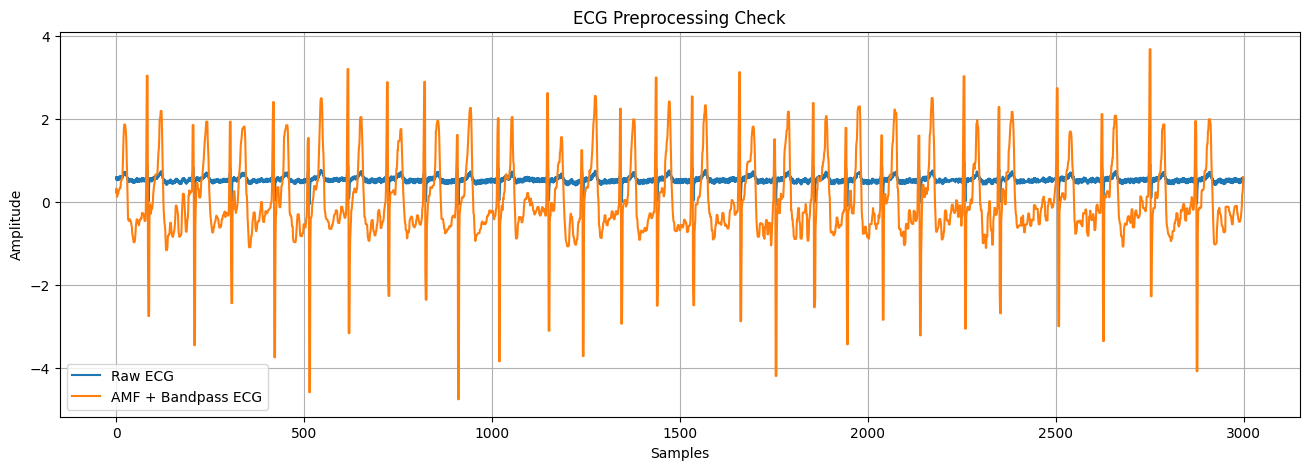

NameError: name 'ecg_segments2' is not defined

<Figure size 1400x400 with 0 Axes>

In [3]:
import matplotlib.pyplot as plt

# ==========================
# VISUAL CHECK
# ==========================

df = pd.read_csv(
    os.path.join(
        ROOT,
        files[0]
    )
)

raw = (
    df["ECG"]
    .values
    .astype(np.float32)
)

filtered = bandpass_ecg(raw)

clean = amf(filtered)

clean = normalize(clean)

plt.figure(
    figsize=(16,5)
)

plt.plot(
    raw[:3000],
    label="Raw ECG"
)

plt.plot(
    clean[:3000],
    label="AMF + Bandpass ECG"
)

plt.legend()

plt.title(
    "ECG Preprocessing Check"
)

plt.xlabel(
    "Samples"
)

plt.ylabel(
    "Amplitude"
)

plt.grid()

plt.show()


# ==========================
# SEGMENT CHECK
# ==========================

plt.figure(
    figsize=(14,4)
)

plt.plot(
    ecg_segments2[0]
)

plt.title(
    "ECG Segment 1"
)

plt.xlabel(
    "Samples"
)

plt.grid()

plt.show()